In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.neighbors import KernelDensity

from msi.gaussian_mixture.gaussian_mixture_model import ConditionalGMM
from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters

23-07-21 01:43:52    scales.py INF   Setting up healpy to run on 256 CPUs 


In [3]:
method_label = "gaussian_mixture"

# network predictions

### choose a run

In [4]:
base_dir = "/pscratch/sd/a/athomsen/run_files/v3"
# base_dir = "/Users/arne/data/DESY3/models/v3/"

In [5]:
# # clustering only
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"
# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg"]

In [6]:
# # clustering only, with and without survey systematics
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# # without survey systematics
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
    
# print(no_survey_systematics_fidu_vali_preds.shape)


In [7]:
# lensing only
model_dir = "2023-05-29_09-55-49_resnet_vanilla"
n_steps = 50000
params = ["Om", "s8", "Aia", "n_Aia"]

In [8]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000
# params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

### general

In [9]:
fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = input_output.load_preds(base_dir, model_dir, n_steps)

out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_gaussian_mixture"

23-07-21 01:43:53 input_output INF   Array shapes:
 
23-07-21 01:43:53 input_output INF   fidu_train_preds =   (750, 4) 
23-07-21 01:43:53 input_output INF   fidu_vali_preds =    (50, 4) 
23-07-21 01:43:53 input_output INF   grid_preds =         (2499, 16, 4) 
23-07-21 01:43:53 input_output INF   grid_cosmos =        (2499, 4) 
23-07-21 01:43:53 input_output INF   grid_sobol =         (2499, 4) 


### observation

In [10]:
obs_pred = np.median(fidu_vali_preds, axis=0)

# Gaussian mixture model

In [11]:
preds = np.concatenate(grid_preds, axis=0)
thetas = np.repeat(grid_cosmos, preds.shape[0]//grid_cosmos.shape[0], axis=0)

print(preds.shape)
print(thetas.shape)

(39984, 4)
(39984, 4)


In [12]:
# p(y | x) <=> p(summary | theta)
model = ConditionalGMM(
    # theta
    x_dim=thetas.shape[1],
    # summary
    y_dim=preds.shape[1],
    out_dir="/pscratch/sd/a/athomsen/run_files/debug/GMM",
    n_gaussians=4,
    u_units=256,
    n_layers=3,
    activation="relu",
    input_noise_sig=0.0,
    tune_hyperparams=False,
)

23-07-21 01:43:55 gaussian_mix INF   Created GMM model with n_params = 214076 
Model: "gaussian_mixture_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNoi  (None, 4)                0         
 se)                                                             
                                                                 
 dense (Dense)               (None, 256)               1280      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (N

In [13]:
fit_history = model.fit(
    x=thetas,
    y=preds,
    epochs=1000,
    batch_size=2499,
    early_stopping_callback=True,
    learning_rate_callback=True,
)

23-07-21 01:43:55 gaussian_mix INF   Fitted the x and y scalers 


epoch:  60%|██████    | 605/1000 [01:01<00:37, 10.55it/s, loss=-14.8, val_loss=-14.5, lr=5.63e-5] 

Restoring model weights from the end of the best epoch: 506.


epoch:  61%|██████    | 606/1000 [01:01<00:37, 10.49it/s, loss=-14.8, val_loss=-14.4, lr=5.63e-5]

Epoch 606: early stopping


epoch:  61%|██████    | 606/1000 [01:01<00:39,  9.90it/s, loss=-14.8, val_loss=-14.4, lr=5.63e-5]

23-07-21 01:44:56 gaussian_mix INF   Finished training 


23-07-21 01:44:56 gaussian_mix INF   Saved the model in /pscratch/sd/a/athomsen/run_files/debug/GMM 


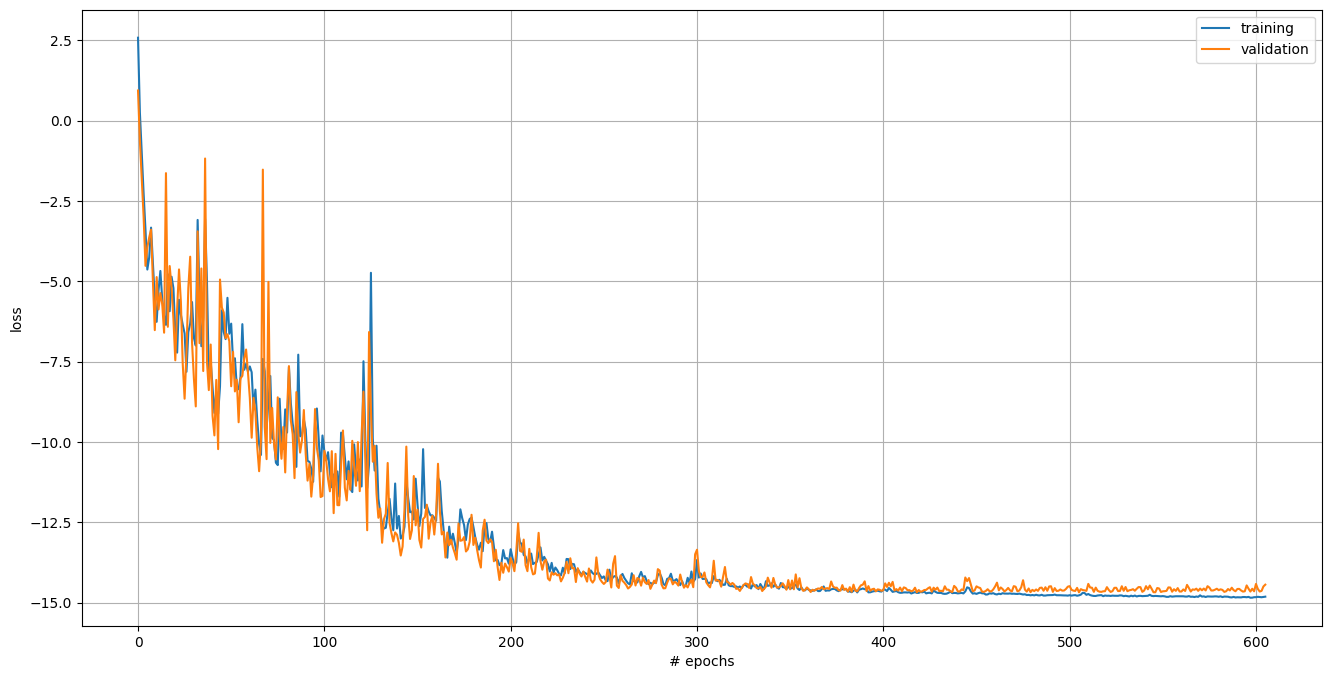

In [14]:
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(fit_history.history["loss"], label="training")
ax.plot(fit_history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear")
ax.grid(True)

## density estimation tests

In [15]:
n_cosmos = grid_cosmos.shape[0]
n_summaries = grid_preds.shape[-1]
n_samples_per_cosmo = 1000

pred_samples = model.sample(grid_cosmos, n_samples_per_cond=n_samples_per_cosmo, batch_size=10000)
print(pred_samples.shape)

100%|████████████████████████████|   | 1/1 [00:00<00:00,  1.17it/s]           drawing samples with batch_size=10000
(1000, 2499, 4)


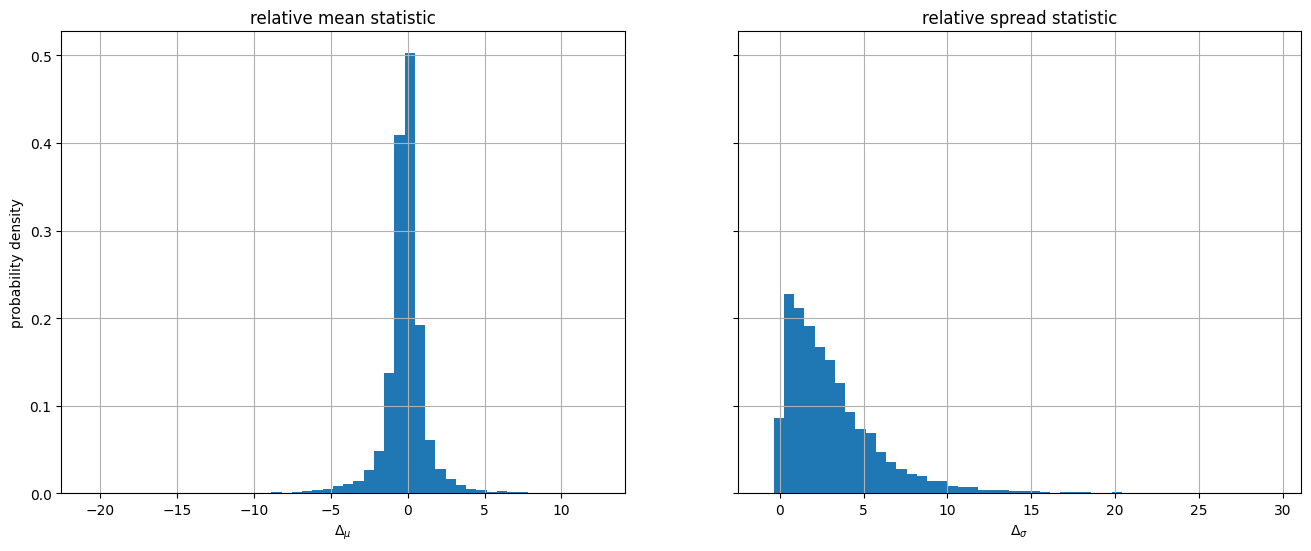

In [16]:
# samples from the mixture model
mean_samples = np.mean(pred_samples, axis=0)
std_samples = np.std(pred_samples, axis=0)

# "true" network predictions
mean_preds = np.mean(grid_preds, axis=1)
std_preds = np.std(grid_preds, axis=1)

assert mean_samples.shape == std_samples.shape == mean_preds.shape == std_preds.shape

# test statistics, these should be tightly centered around zero
Delta_mu = (mean_samples - mean_preds)/std_preds
Delta_sigma = (std_samples - std_preds)/std_preds

Delta_mu = Delta_mu.ravel()
Delta_sigma = Delta_sigma.ravel()

# plot
fig, ax = plt.subplots(ncols=2, figsize=(16,6), sharey=True)

ax[0].hist(Delta_mu, bins=50, density=True)
ax[0].set(title="relative mean statistic", xlabel=r"$\Delta_\mu$", ylabel="probability density")
ax[0].grid(True)

ax[1].hist(Delta_sigma, bins=50, density=True)
ax[1].set(title="relative spread statistic", xlabel=r"$\Delta_\sigma$")
ax[1].grid(True)

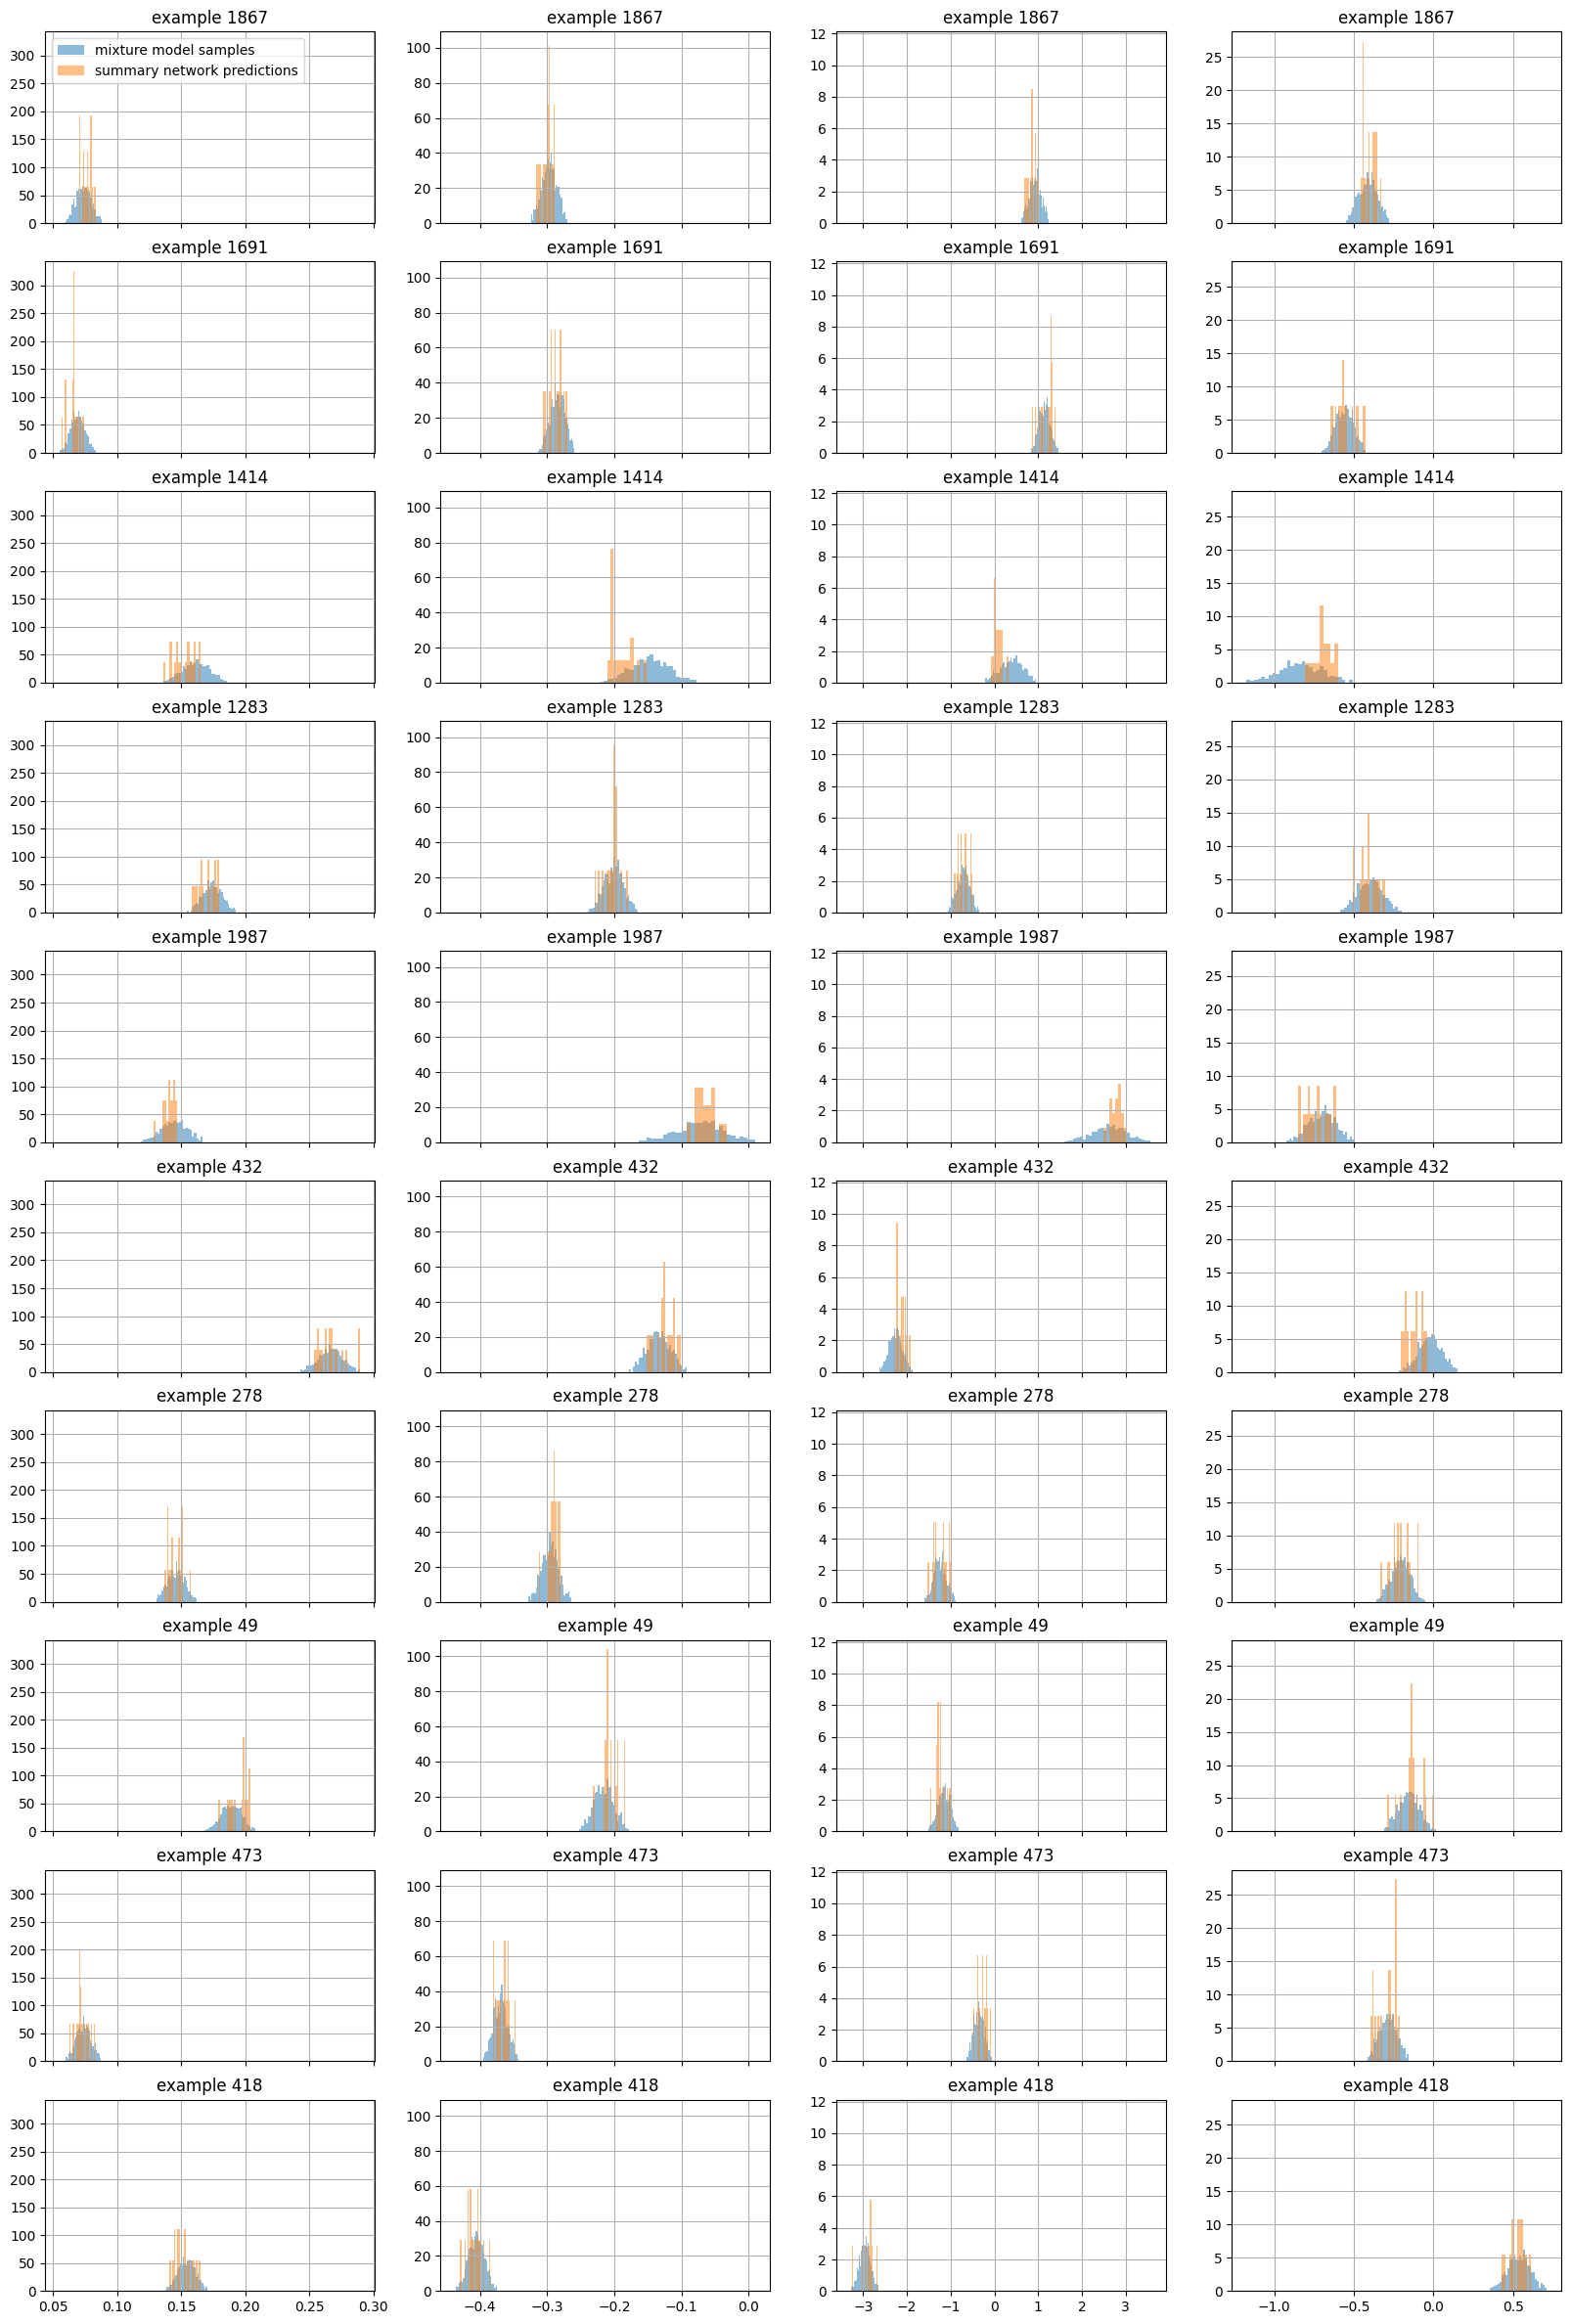

In [17]:
n_indices = 10

fig, ax = plt.subplots(figsize=(5*n_summaries, 3*n_indices), nrows=n_indices, ncols=n_summaries, sharex="col", sharey="col")

cosmo_indices = np.random.randint(0, n_cosmos, n_indices)
for i, i_cosmo in enumerate(cosmo_indices):
    for j in range(n_summaries):
        current_sample = pred_samples[:,i_cosmo,j]
        current_true = grid_preds[i_cosmo,:,j]
                
        current_all = np.concatenate([current_sample, current_true]).ravel()
        current_min = np.quantile(current_all, 0.01)
        current_max = np.quantile(current_all, 0.99)
        current_bins = np.linspace(current_min, current_max, 30)

        ax[i,j].hist(current_sample, bins=current_bins, density=True, label="mixture model samples", alpha=0.5)
        ax[i,j].hist(current_true, bins=current_bins, density=True, label="summary network predictions", alpha=0.5)

        # cosmetics
        ax[i,j].set(title=f"example {i_cosmo}")
        ax[i,j].grid(True)
        
        if i==0 and j==0:
            ax[i,j].legend(loc="upper left")

100%|██████████| 2499/2499 [00:00<00:00, 11909.84it/s]


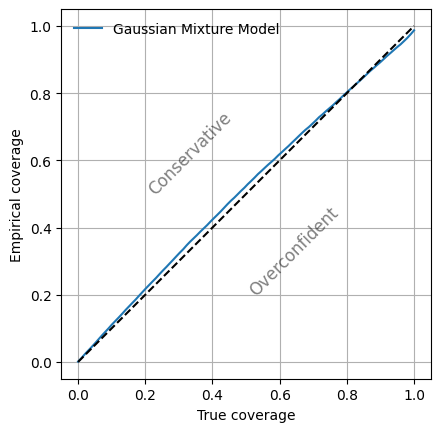

In [18]:
n_confidence_levels = 100
n_examples = grid_preds.shape[1]

# shape (n_cosmos, n_examples, n_summary)
true_preds = grid_preds

# shape (n_cosmos, n_examples)
true_probs = np.exp(model.log_likelihood(np.repeat(grid_cosmos[:,np.newaxis,:], true_preds.shape[1], axis=1), true_preds))

# shape (n_cosmos, n_samples_per_cosmo)
sample_log_probs = model.log_likelihood(np.repeat(grid_cosmos[np.newaxis,:,:], pred_samples.shape[0], axis=0), pred_samples).T

# empirical expected coverage probability
eecp = np.zeros((n_cosmos, n_examples, n_confidence_levels))

# cosmos
for i in tqdm(range(n_cosmos)):
    true_cosmo = grid_cosmos[i]
    
    sample_log_prob = sample_log_probs[i]
    sample_prob = np.sort(np.exp(sample_log_prob))[::-1]
    
    # shape (n_conficence_levels,)
    prob_at_cls = sample_prob[::n_samples_per_cosmo//n_confidence_levels]
    
    # examples
    for j in range(n_examples):
        true_pred = true_preds[i,j]    
        true_prob = true_probs[i,j]

        # per cosmology
        eecp[i,j] = true_prob >= prob_at_cls

# mean over all cosmologies and examples
eecp = np.mean(eecp, axis=(0,1))

# plot
true_coverage = np.linspace(0, 1, n_confidence_levels)

fig, ax = plt.subplots()

ax.plot(true_coverage, eecp, label="Gaussian Mixture Model")
ax.plot([0, 1], [0, 1], color="k", linestyle="--")

ax.set(xlabel="True coverage", ylabel="Empirical coverage")
ax.text(0.2, 0.5, "Conservative", fontsize="large", alpha=0.5, rotation=45)
ax.text(0.5, 0.2, "Overconfident", fontsize="large", alpha=0.5, rotation=45)
ax.set_aspect("equal")
ax.legend(loc="upper left", frameon=False)
ax.grid(True)

## MCMC

In [19]:
tf_pred = tf.cast(obs_pred, dtype=tf.float32)
tf_pred = tf.expand_dims(tf_pred, axis=0)

def log_likelihood(X): 
    # evaluate the normal distribution
    log_prob = model.log_likelihood(X, tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=None)

    return log_prob

In [20]:
chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
)

23-07-21 01:45:07      mcmc.py INF   Initial values in prior: True 


100%|██████████| 1000/1000 [02:22<00:00,  7.01it/s]


## plot

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

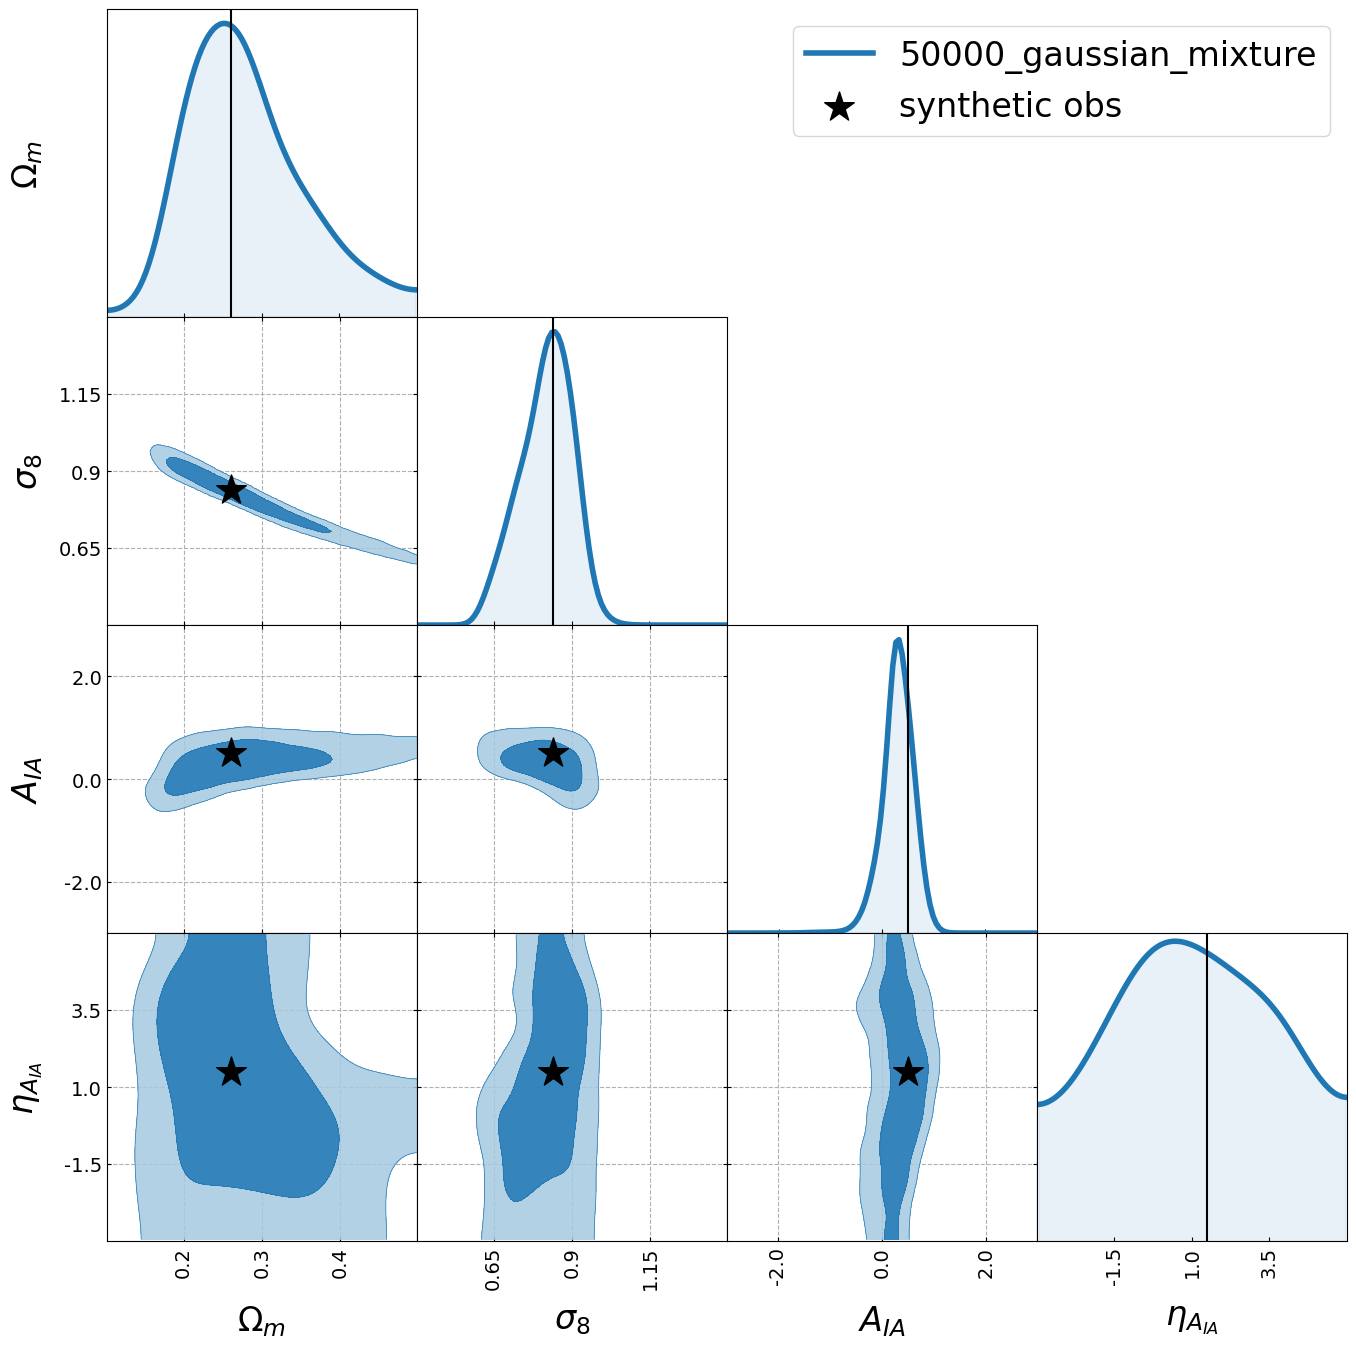

In [21]:
plotting.plot_chains(
    chain, 
    params, 
    out_dir=out_dir, 
    labels=label,
)